In [14]:
import yfinance as yf
import pandas as pd
from datetime import date

def get_stock_snapshot(ticker, start, end=None):
    """
    Gather price history, technical indicators, fundamentals, and analyst
    sentiment for a single ticker, to support (not replace) investment research.

    Parameters
    ----------
    ticker : str
        Stock ticker, e.g. "AAPL"
    start, end : str
        Date range, format "YYYY-MM-DD". Defaults to today if not provided.

    Returns
    -------
    dict with keys: 'price_data', 'technicals', 'fundamentals', 'recommendations'
    """
    
    if end is None:
        end = date.today().strftime("%Y-%m-%d")
        
    stock = yf.Ticker(ticker)

    # --- Price history ---
    price_data = stock.history(start=start, end=end)
    price_data.reset_index(inplace=True)

    # --- Technical indicators ---
    price_data['SMA_20'] = price_data['Close'].rolling(20).mean()
    price_data['SMA_50'] = price_data['Close'].rolling(50).mean()
    price_data['daily_return'] = price_data['Close'].pct_change()
    price_data['volatility_20d'] = price_data['daily_return'].rolling(20).std()

    technicals = {
        'current_price': price_data['Close'].iloc[-1],
        'sma_20': price_data['SMA_20'].iloc[-1],
        'sma_50': price_data['SMA_50'].iloc[-1],
        'trend': 'bullish' if price_data['SMA_20'].iloc[-1] > price_data['SMA_50'].iloc[-1] else 'bearish',
        'volatility_20d': price_data['volatility_20d'].iloc[-1],
        '52wk_high': price_data['Close'].max(),
        '52wk_low': price_data['Close'].min(),
    }

    # --- Fundamentals ---
    info = stock.info
    fundamentals = {
        'market_cap': info.get('marketCap'),
        'pe_ratio': info.get('trailingPE'),
        'forward_pe': info.get('forwardPE'),
        'peg_ratio': info.get('pegRatio'),
        'dividend_yield': info.get('dividendYield'),
        'profit_margin': info.get('profitMargins'),
        'debt_to_equity': info.get('debtToEquity'),
        'sector': info.get('sector'),
        'industry': info.get('industry'),
    }

    # --- Analyst sentiment ---
    try:
        recs = stock.recommendations
        recent_rec = recs.tail(1).to_dict('records')[0] if recs is not None and not recs.empty else None
    except Exception:
        recent_rec = None
        
    plot_price_with_indicators(price_data, ticker)

    return {
        'price_data': price_data,
        'technicals': technicals,
        'fundamentals': fundamentals,
        'recommendations': recent_rec,
    }

In [12]:
import matplotlib.pyplot as plt

def plot_price_with_indicators(price_data, ticker):
    fig, ax = plt.subplots(figsize=(12, 6))

    # Main price and moving averages
    ax.plot(price_data['Date'], price_data['Close'], label='Close Price', color='black', linewidth=1.5)
    ax.plot(price_data['Date'], price_data['SMA_20'], label='SMA 20', color='blue', linewidth=1)
    ax.plot(price_data['Date'], price_data['SMA_50'], label='SMA 50', color='orange', linewidth=1)

    # Horizontal lines for high/low
    high = price_data['Close'].max()
    low = price_data['Close'].min()
    ax.axhline(high, color='green', linestyle='--', linewidth=1, label=f'High (${high:.2f})')
    ax.axhline(low, color='red', linestyle='--', linewidth=1, label=f'Low (${low:.2f})')

    ax.set_title(f'{ticker} Price with Moving Averages')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price ($)')
    ax.legend()
    plt.tight_layout()
    plt.show()

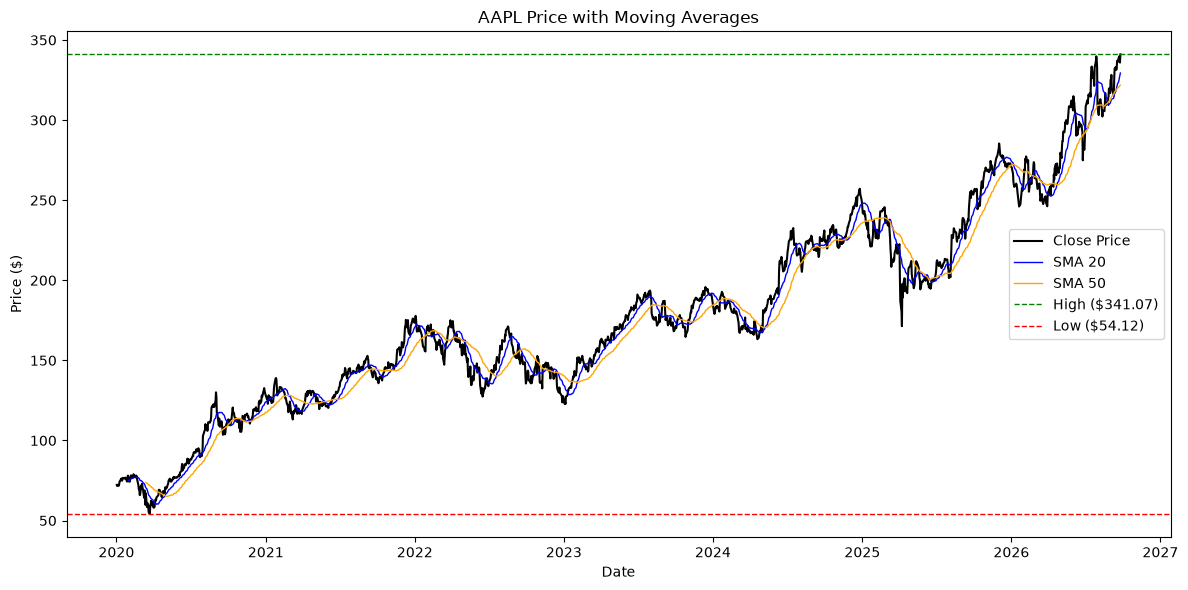

In [15]:
snapshot = get_stock_snapshot("AAPL", "2020-01-01")


In [5]:
import pandas as pd
import requests
from io import StringIO

headers = {'User-Agent': 'Mozilla/5.0'}
response = requests.get('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies', headers=headers)
sp500 = pd.read_html(StringIO(response.text))[0]

sp500['Symbol'] = sp500['Symbol'].str.replace('.', '-', regex=False)  # yfinance format
tickers = sp500['Symbol'].tolist()
print(len(tickers))  

503


In [7]:
import yfinance as yf
import time

def build_sp500_table(tickers, delay=0.5):
    rows = []
    for i, ticker in enumerate(tickers):
        try:
            stock = yf.Ticker(ticker)
            info = stock.info
            hist = stock.history(period="3mo")

            if hist.empty:
                continue

            sma_20 = hist['Close'].rolling(20).mean().iloc[-1]
            sma_50 = hist['Close'].rolling(50).mean().iloc[-1]
            current_price = hist['Close'].iloc[-1]

            rows.append({
                'ticker': ticker,
                'sector': info.get('sector'),
                'market_cap': info.get('marketCap'),
                'pe_ratio': info.get('trailingPE'),
                'forward_pe': info.get('forwardPE'),
                'dividend_yield': info.get('dividendYield'),
                'profit_margin': info.get('profitMargins'),
                'current_price': current_price,
                'sma_20': sma_20,
                'sma_50': sma_50,
                'trend': 'bullish' if sma_20 > sma_50 else 'bearish',
            })
        except Exception as e:
            print(f"Skipped {ticker}: {e}")

        if i % 50 == 0:
            print(f"Processed {i}/{len(tickers)}")

        time.sleep(delay)  # be polite to Yahoo's servers, avoid rate-limiting

    return pd.DataFrame(rows)

In [8]:
sp500_table = build_sp500_table(tickers)
sp500_table = sp500_table.sort_values('market_cap', ascending=False).reset_index(drop=True)
sp500_table.head(20)

Processed 0/503
Processed 50/503
Processed 100/503
Processed 150/503
Processed 200/503
Processed 250/503
Processed 300/503
Processed 350/503
Processed 400/503
Processed 450/503
Processed 500/503


,ticker,sector,market_cap,pe_ratio,forward_pe,dividend_yield,profit_margin,current_price,sma_20,sma_50,trend
0,NVDA,Technology,5434765213696,28.489874,14.351548,0.44,0.63663,225.070007,221.654555,215.794765,bullish
1,AAPL,Technology,4977636933632,39.068733,35.582424,0.32,0.27619,341.070007,329.396001,321.742802,bullish
2,GOOGL,Communication Services,4206119354368,17.273733,23.083103,0.26,0.54771,343.920013,342.119380,344.135312,bearish
3,GOOG,Communication Services,4171386060800,17.122490,22.892488,0.26,0.54771,341.079987,338.746896,341.847393,bearish
4,MSFT,Technology,3832843862016,28.739979,21.801512,0.76,0.40305,516.169983,500.040500,475.404052,bullish
5,AMZN,Consumer Cyclical,2693018681344,20.086080,24.021444,NaN,0.17440,249.669998,254.306000,256.175000,bearish
6,META,Communication Services,1914858373120,28.332453,21.496538,0.28,0.29835,751.659973,660.486270,615.319999,bullish
7,AVGO,Technology,1684184367104,45.582687,18.201180,0.74,0.42944,352.809998,357.543480,376.005532,bearish
8,TSLA,Consumer Cyclical,1469666033664,344.546260,171.251190,NaN,0.03671,372.109985,365.684497,348.248598,bullish
9,MU,Technology,1222319669248,24.447256,6.785805,0.05,0.55906,1082.280029,994.142502,941.615203,bullish


In [9]:
import sqlite3

conn = sqlite3.connect('../data/finance.db')
sp500_table.to_sql('sp500_snapshot', conn, if_exists='replace', index=False)

503

In [10]:
pd.read_sql('SELECT * FROM sp500_snapshot LIMIT 10', conn)

,ticker,sector,market_cap,pe_ratio,forward_pe,dividend_yield,profit_margin,current_price,sma_20,sma_50,trend
0,NVDA,Technology,5434765213696,28.489874,14.351548,0.44,0.63663,225.070007,221.654555,215.794765,bullish
1,AAPL,Technology,4977636933632,39.068733,35.582424,0.32,0.27619,341.070007,329.396001,321.742802,bullish
2,GOOGL,Communication Services,4206119354368,17.273733,23.083103,0.26,0.54771,343.920013,342.119380,344.135312,bearish
3,GOOG,Communication Services,4171386060800,17.122490,22.892488,0.26,0.54771,341.079987,338.746896,341.847393,bearish
4,MSFT,Technology,3832843862016,28.739979,21.801512,0.76,0.40305,516.169983,500.040500,475.404052,bullish
5,AMZN,Consumer Cyclical,2693018681344,20.086080,24.021444,NaN,0.17440,249.669998,254.306000,256.175000,bearish
6,META,Communication Services,1914858373120,28.332453,21.496538,0.28,0.29835,751.659973,660.486270,615.319999,bullish
7,AVGO,Technology,1684184367104,45.582687,18.201180,0.74,0.42944,352.809998,357.543480,376.005532,bearish
8,TSLA,Consumer Cyclical,1469666033664,344.546260,171.251190,NaN,0.03671,372.109985,365.684497,348.248598,bullish
9,MU,Technology,1222319669248,24.447256,6.785805,0.05,0.55906,1082.280029,994.142502,941.615203,bullish


In [11]:
conn.close()

In [12]:
sp500.to_csv('../data/sp500_companies.csv', index=False)